# Taller: Clasificación de Películas con Perceptrón

Curso: Inteligencia Artificial / Machine Learning

Duración estimada: 2–3 horas

Objetivo: Utilizar un **Perceptrón** para clasificar películas como **exitosas o no exitosas** usando el dataset de Kaggle **TMDB 5000 Movies**.

Dataset:
https://www.kaggle.com/datasets/tmdb/tmdb-movie-metadata

Archivo principal: `tmdb_5000_movies.csv`

## 1. Introducción

El **Perceptrón** es uno de los algoritmos más antiguos de aprendizaje automático.

Este modelo intenta encontrar una **frontera de decisión lineal** que separe dos clases.

En este taller intentaremos clasificar películas según su éxito utilizando información del dataset.

Preguntas guía:

- ¿Las películas exitosas pueden separarse linealmente?
- ¿Qué características ayudan más a la clasificación?
- ¿Qué limitaciones tiene el perceptrón?

## 2. Carga del Dataset

Pasos:

1. Descargar el dataset desde Kaggle.
2. Cargar el archivo `tmdb_5000_movies.csv`.
3. Mostrar:
   - número de registros
   - número de columnas
   - nombres de las variables
   - tipos de datos

Utilizar **pandas** para explorar el dataset.

In [4]:
# Carga del dataset y librerías base
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

# Buscar datasets disponibles en la carpeta actual
candidate_files = [
    Path('tmdb_5000_movies.csv'),
    Path('tmdb_5000.csv'),
    Path('tmdb_5000_credits.csv'),
    Path('TMDB_5000_movies.csv'),
    Path('TMDB_5000.csv'),
    Path('TMDB_5000_credits.csv'),
]

data_path = next((p for p in candidate_files if p.exists()), None)

if data_path is None:
    available_csv = sorted([p.name for p in Path('.').glob('*.csv')])
    raise FileNotFoundError(
        'No se encontró el dataset. Archivos CSV detectados en esta carpeta: ' + str(available_csv)
    )

df_raw = pd.read_csv(data_path)
print(f'Archivo cargado: {data_path.name}')
print(f'Registros: {df_raw.shape[0]}')
print(f'Columnas: {df_raw.shape[1]}')
print('\nPrimeras columnas:')
print(df_raw.columns.tolist()[:15])
print('\nTipos de datos (primeras 15):')
display(df_raw.dtypes.head(15))

# Detectar modo de trabajo: movies (original) o credits (alternativo)
movie_required_cols = {'budget', 'popularity', 'runtime', 'vote_average', 'vote_count', 'revenue'}
credits_required_cols = {'movie_id', 'title', 'cast', 'crew'}

if movie_required_cols.issubset(set(df_raw.columns)):
    dataset_mode = 'movies'
    df = df_raw.copy()
elif credits_required_cols.issubset(set(df_raw.columns)):
    dataset_mode = 'credits'

    def safe_len_json_list(text):
        try:
            arr = json.loads(text) if isinstance(text, str) else []
            return len(arr) if isinstance(arr, list) else 0
        except Exception:
            return 0

    def count_jobs(text, valid_jobs):
        try:
            arr = json.loads(text) if isinstance(text, str) else []
            if not isinstance(arr, list):
                return 0
            return sum(1 for x in arr if isinstance(x, dict) and x.get('job') in valid_jobs)
        except Exception:
            return 0

    df = df_raw.copy()
    df['cast_size'] = df['cast'].apply(safe_len_json_list)
    df['crew_size'] = df['crew'].apply(safe_len_json_list)
    df['n_directors'] = df['crew'].apply(lambda s: count_jobs(s, {'Director'}))
    df['n_writers'] = df['crew'].apply(lambda s: count_jobs(s, {'Writer', 'Screenplay', 'Story'}))
    df['title_length'] = df['title'].astype(str).str.len()
else:
    raise ValueError('El CSV no coincide con formato movies ni credits de TMDB 5000.')

print(f'\nModo detectado: {dataset_mode}')

Archivo cargado: tmdb_5000_credits.csv
Registros: 4803
Columnas: 4

Primeras columnas:
['movie_id', 'title', 'cast', 'crew']

Tipos de datos (primeras 15):


movie_id    int64
title         str
cast          str
crew          str
dtype: object


Modo detectado: credits


## 3. Exploración de Variables

Seleccione variables numéricas relevantes.

Ejemplos:

- budget
- popularity
- runtime
- vote_average
- vote_count
- revenue

Analice:

- estadísticas descriptivas
- correlaciones
- distribución de variables

In [ ]:
# Exploración rápida
print('Dimensión del dataset:', df.shape)
df.head(5)

(4803, 20)

In [ ]:
# Nombres de columnas
pd.Series(df.columns, name='columnas')

Index(['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language',
       'original_title', 'overview', 'popularity', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'vote_average',
       'vote_count'],
      dtype='object')

In [ ]:
# Estadísticas descriptivas de variables numéricas
df.describe(include=[np.number]).T

,budget,id,popularity,revenue,runtime,vote_average,vote_count
count,4.803000e+03,4803.000000,4803.000000,4.803000e+03,4801.000000,4803.000000,4803.000000
mean,2.904504e+07,57165.484281,21.492301,8.226064e+07,106.875859,6.092172,690.217989
std,4.072239e+07,88694.614033,31.816650,1.628571e+08,22.611935,1.194612,1234.585891
min,0.000000e+00,5.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000
25%,7.900000e+05,9014.500000,4.668070,0.000000e+00,94.000000,5.600000,54.000000
50%,1.500000e+07,14629.000000,12.921594,1.917000e+07,103.000000,6.200000,235.000000
75%,4.000000e+07,58610.500000,28.313505,9.291719e+07,118.000000,6.800000,737.000000
max,3.800000e+08,459488.000000,875.581305,2.787965e+09,338.000000,10.000000,13752.000000


## 4. Definición de la Variable Objetivo

Defina una variable llamada **success**.

Ejemplo de criterio:

- success = 1 si vote_average >= 7
- success = 0 en otro caso

También puede probar otros criterios como:

- revenue > budget

In [5]:
# Definir variables numéricas relevantes según el dataset cargado
if dataset_mode == 'movies':
    features = ['budget', 'popularity', 'runtime', 'vote_average', 'vote_count', 'revenue']
else:
    features = ['cast_size', 'crew_size', 'n_directors', 'n_writers', 'title_length']

missing_features = [col for col in features if col not in df.columns]
if missing_features:
    raise ValueError(f'Faltan columnas en el dataset: {missing_features}')

df = df[features].copy()
print('Features usadas:', features)
df.head()

Features usadas: ['cast_size', 'crew_size', 'n_directors', 'n_writers', 'title_length']


,cast_size,crew_size,n_directors,n_writers,title_length
0,83,153,1,2,6
1,34,32,1,2,40
2,83,155,1,7,7
3,158,217,1,4,21
4,27,132,1,3,11


In [6]:
# Definición de variable objetivo success
if dataset_mode == 'movies':
    # Criterio base del taller
    df['success'] = (df['vote_average'] >= 7).astype(int)
    criterio = 'success = 1 si vote_average >= 7'
else:
    # Criterio alternativo para credits-only: elenco por encima de la mediana
    threshold = df['cast_size'].median()
    df['success'] = (df['cast_size'] >= threshold).astype(int)
    criterio = f'success = 1 si cast_size >= mediana ({threshold:.1f})'

print('Criterio aplicado:', criterio)
print('Distribución de la variable success:')
display(df['success'].value_counts().rename('conteo').to_frame())
display(df.head())

Criterio aplicado: success = 1 si cast_size >= mediana (16.0)
Distribución de la variable success:


,conteo
success,
1,2647
0,2156


,cast_size,crew_size,n_directors,n_writers,title_length,success
0,83,153,1,2,6,1
1,34,32,1,2,40,1
2,83,155,1,7,7,1
3,158,217,1,4,21,1
4,27,132,1,3,11,1


## 5. Limpieza de Datos

Realizar:

- eliminación de valores faltantes
- eliminación de columnas irrelevantes
- selección de features
- normalización o estandarización de variables

Preguntas:

- ¿Cuántos registros quedan después de limpiar el dataset?
- ¿Qué variables parecen más informativas?

Valores faltantes por columna (antes):


,faltantes
cast_size,0
crew_size,0
n_directors,0
n_writers,0
title_length,0
success,0


Registros después de limpiar: 4623
Resumen de features escaladas:


,count,mean,std,min,25%,50%,75%,max
cast_size,4623.0,-2.459157e-17,1.000108,-1.139593,-0.533445,-0.280883,0.173729,10.175180
crew_size,4623.0,-4.918314e-17,1.000108,-0.868395,-0.618083,-0.336483,0.195429,12.742290
n_directors,4623.0,-1.871265e-16,1.000108,-2.154589,-0.158864,-0.158864,-0.158864,39.755641
n_writers,4623.0,3.688736e-17,1.000108,-1.308574,-0.550297,-0.550297,0.207981,13.856977
title_length,4623.0,-7.992261e-17,1.000108,-1.691377,-0.634708,-0.165077,0.421962,8.288279


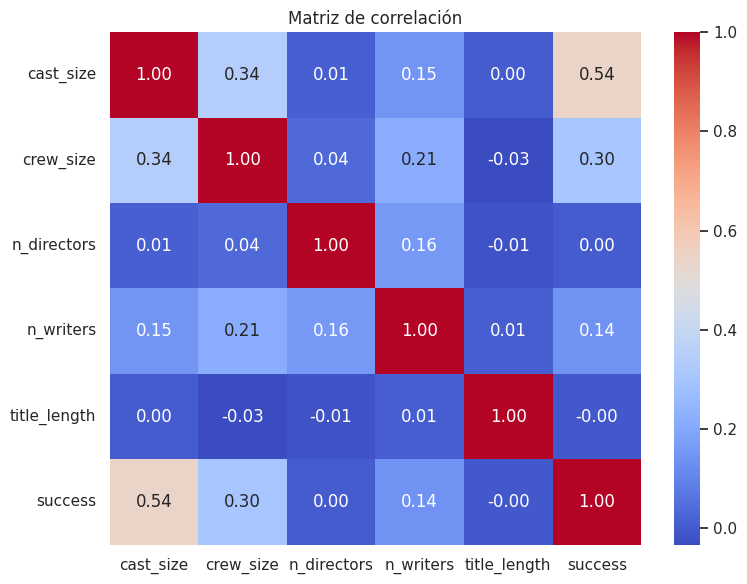

In [7]:
# Limpieza y normalización
from sklearn.preprocessing import StandardScaler

print('Valores faltantes por columna (antes):')
display(df.isna().sum().to_frame('faltantes'))

df_clean = df.dropna().drop_duplicates().copy()
print(f'Registros después de limpiar: {df_clean.shape[0]}')

X_cols = [c for c in df_clean.columns if c != 'success']
X = df_clean[X_cols].copy()
y = df_clean['success'].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X_cols, index=X.index)

print('Resumen de features escaladas:')
display(X_scaled_df.describe().T)

# Correlaciones para discutir variables informativas
plt.figure(figsize=(8, 6))
sns.heatmap(df_clean[X_cols + ['success']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de correlación')
plt.tight_layout()
plt.show()

## 6. Análisis de Separabilidad Lineal

Antes de entrenar el perceptrón debemos analizar si las clases parecen **linealmente separables**.

Actividades:

1. Seleccionar dos variables.
2. Construir un gráfico de dispersión.
3. Colorear por clase.

Probar varias combinaciones:

- vote_average vs popularity
- vote_average vs vote_count
- budget vs revenue
- runtime vs popularity

Preguntas:

- ¿Se observa una frontera aproximadamente lineal?
- ¿Las clases están mezcladas?

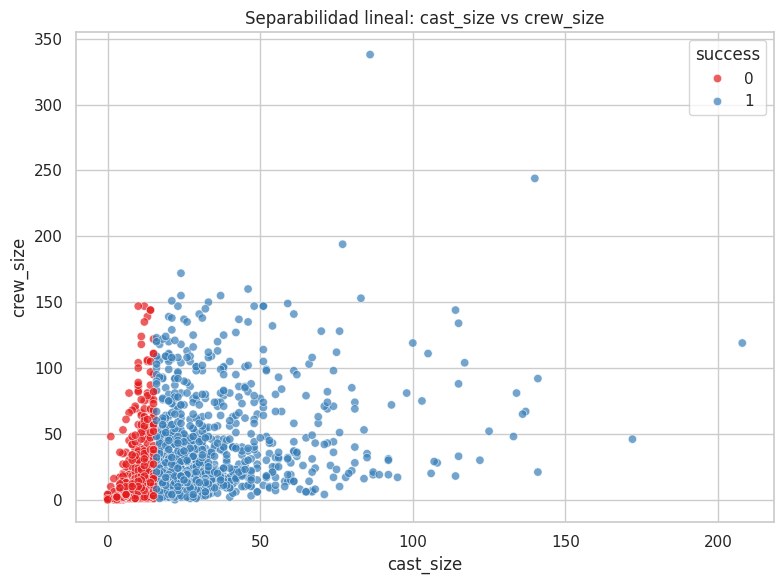

Si quieres, cambia x_var/y_var para probar otras combinaciones.


In [8]:
# Análisis de separabilidad lineal con dos variables
if dataset_mode == 'movies':
    x_var, y_var = 'vote_average', 'popularity'
else:
    x_var, y_var = 'cast_size', 'crew_size'

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_clean.sample(min(2000, len(df_clean)), random_state=42),
    x=x_var,
    y=y_var,
    hue='success',
    alpha=0.7,
    palette='Set1'
 )
plt.title(f'Separabilidad lineal: {x_var} vs {y_var}')
plt.legend(title='success')
plt.tight_layout()
plt.show()

print('Si quieres, cambia x_var/y_var para probar otras combinaciones.')

## 7. Entrenamiento del Perceptrón

Utilizar **scikit-learn** para entrenar el modelo.

Pasos:

1. Separar datos en **train** y **test**.
2. Crear el modelo Perceptrón.
3. Entrenar el modelo.
4. Realizar predicciones.

In [9]:
# Entrenamiento del Perceptrón
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Perceptron

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled_df, y, test_size=0.25, random_state=42, stratify=y
)

perceptron = Perceptron(max_iter=2000, eta0=0.01, random_state=42)
perceptron.fit(X_train, y_train)

y_pred = perceptron.predict(X_test)
print('Modelo entrenado correctamente.')

Modelo entrenado correctamente.


## 8. Evaluación del Modelo

Evaluar el modelo utilizando:

- accuracy
- precision
- recall
- matriz de confusión

Analice:

- ¿El modelo clasifica bien?
- ¿Qué errores comete?

Accuracy : 0.9853
Precision: 0.9862
Recall   : 0.9877

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       503
           1       0.99      0.99      0.99       653

    accuracy                           0.99      1156
   macro avg       0.99      0.98      0.99      1156
weighted avg       0.99      0.99      0.99      1156



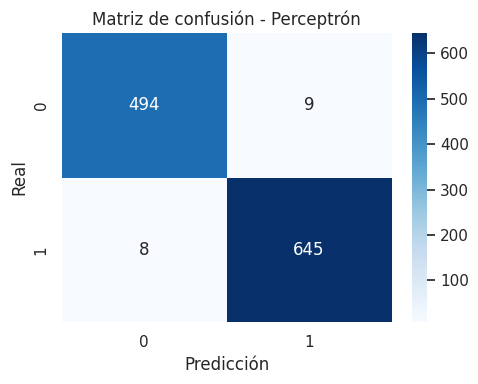

In [10]:
# Evaluación del modelo
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
cm = confusion_matrix(y_test, y_pred)

print(f'Accuracy : {acc:.4f}')
print(f'Precision: {prec:.4f}')
print(f'Recall   : {rec:.4f}')
print('\nReporte de clasificación:')
print(classification_report(y_test, y_pred, zero_division=0))

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de confusión - Perceptrón')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

## 9. Frontera de Decisión

Seleccione dos variables y visualice:

- datos
- frontera de decisión

Analice:

- puntos mal clasificados
- posición de la frontera

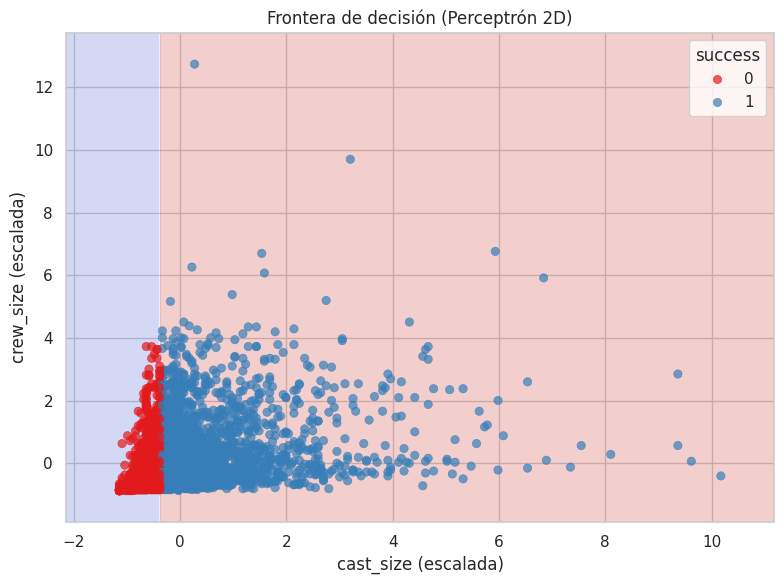

Accuracy modelo 2D: 1.0000


In [11]:
# Frontera de decisión con 2 variables
from sklearn.preprocessing import StandardScaler

if dataset_mode == 'movies':
    vars_2d = ['vote_average', 'popularity']
else:
    vars_2d = ['cast_size', 'crew_size']

X2 = df_clean[vars_2d].copy()
y2 = df_clean['success'].copy()

scaler_2d = StandardScaler()
X2_scaled = scaler_2d.fit_transform(X2)

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2_scaled, y2, test_size=0.25, random_state=42, stratify=y2
)

clf_2d = Perceptron(max_iter=2000, eta0=0.01, random_state=42)
clf_2d.fit(X2_train, y2_train)

x_min, x_max = X2_scaled[:, 0].min() - 1, X2_scaled[:, 0].max() + 1
y_min, y_max = X2_scaled[:, 1].min() - 1, X2_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
grid = np.c_[xx.ravel(), yy.ravel()]
zz = clf_2d.predict(grid).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, zz, alpha=0.25, cmap='coolwarm')
sns.scatterplot(
    x=X2_scaled[:, 0],
    y=X2_scaled[:, 1],
    hue=y2,
    palette='Set1',
    alpha=0.7,
    edgecolor=None
)
plt.title('Frontera de decisión (Perceptrón 2D)')
plt.xlabel(f'{vars_2d[0]} (escalada)')
plt.ylabel(f'{vars_2d[1]} (escalada)')
plt.legend(title='success')
plt.tight_layout()
plt.show()

y2_pred = clf_2d.predict(X2_test)
print(f'Accuracy modelo 2D: {accuracy_score(y2_test, y2_pred):.4f}')

## 10. Experimentos

Realizar los siguientes experimentos:

Experimento 1
- usar solo 2 variables

Experimento 2
- usar 4 variables

Experimento 3
- cambiar la definición de éxito

Experimento 4
- eliminar variables irrelevantes

Comparar resultados.

In [12]:
# Experimentos comparativos
from sklearn.metrics import accuracy_score, precision_score, recall_score

def run_experiment(dataframe, feature_cols, success_mode='vote_average'):
    data = dataframe.copy()

    if dataset_mode == 'movies':
        if success_mode == 'vote_average':
            data['success'] = (data['vote_average'] >= 7).astype(int)
        elif success_mode == 'revenue_budget':
            data['success'] = (data['revenue'] > data['budget']).astype(int)
        else:
            raise ValueError('success_mode no soportado para movies')
    else:
        # credits-only
        if success_mode == 'cast_median':
            threshold = data['cast_size'].median()
            data['success'] = (data['cast_size'] >= threshold).astype(int)
        elif success_mode == 'crew_median':
            threshold = data['crew_size'].median()
            data['success'] = (data['crew_size'] >= threshold).astype(int)
        else:
            raise ValueError('success_mode no soportado para credits')

    cols_needed = list(set(feature_cols + ['success']))
    exp_df = data[cols_needed].dropna().drop_duplicates()
    X_exp = exp_df[feature_cols]
    y_exp = exp_df['success']

    if y_exp.nunique() < 2:
        return None

    scaler_exp = StandardScaler()
    X_exp_scaled = scaler_exp.fit_transform(X_exp)

    X_tr, X_te, y_tr, y_te = train_test_split(
        X_exp_scaled, y_exp, test_size=0.25, random_state=42, stratify=y_exp
    )

    model = Perceptron(max_iter=2000, eta0=0.01, random_state=42)
    model.fit(X_tr, y_tr)
    y_hat = model.predict(X_te)

    return {
        'n_features': len(feature_cols),
        'features': ', '.join(feature_cols),
        'success_mode': success_mode,
        'accuracy': accuracy_score(y_te, y_hat),
        'precision': precision_score(y_te, y_hat, zero_division=0),
        'recall': recall_score(y_te, y_hat, zero_division=0),
        'n_rows': len(exp_df)
    }

# Preparar dataframe base según modo
if dataset_mode == 'movies':
    exp_base = df_raw.copy()
    experiments = [
        ('Experimento 1: 2 variables', ['vote_average', 'popularity'], 'vote_average'),
        ('Experimento 2: 4 variables', ['budget', 'runtime', 'vote_average', 'vote_count'], 'vote_average'),
        ('Experimento 3: éxito alternativo', ['budget', 'popularity', 'runtime', 'revenue'], 'revenue_budget'),
        ('Experimento 4: sin budget', ['popularity', 'runtime', 'vote_average', 'vote_count'], 'vote_average'),
    ]
else:
    exp_base = df_raw.copy()
    exp_base['cast_size'] = exp_base['cast'].apply(lambda s: len(json.loads(s)) if isinstance(s, str) else 0)
    exp_base['crew_size'] = exp_base['crew'].apply(lambda s: len(json.loads(s)) if isinstance(s, str) else 0)
    exp_base['title_length'] = exp_base['title'].astype(str).str.len()

    def count_jobs_local(text, valid_jobs):
        try:
            arr = json.loads(text) if isinstance(text, str) else []
            return sum(1 for x in arr if isinstance(x, dict) and x.get('job') in valid_jobs)
        except Exception:
            return 0

    exp_base['n_directors'] = exp_base['crew'].apply(lambda s: count_jobs_local(s, {'Director'}))
    exp_base['n_writers'] = exp_base['crew'].apply(lambda s: count_jobs_local(s, {'Writer', 'Screenplay', 'Story'}))

    experiments = [
        ('Experimento 1: 2 variables', ['cast_size', 'crew_size'], 'cast_median'),
        ('Experimento 2: 4 variables', ['cast_size', 'crew_size', 'n_directors', 'n_writers'], 'cast_median'),
        ('Experimento 3: éxito alternativo', ['cast_size', 'crew_size', 'title_length'], 'crew_median'),
        ('Experimento 4: sin cast_size', ['crew_size', 'n_directors', 'n_writers', 'title_length'], 'cast_median'),
    ]

results = []
for name, feats, mode in experiments:
    out = run_experiment(exp_base, feats, mode)
    if out is not None:
        out['experimento'] = name
        results.append(out)

results_df = pd.DataFrame(results)[['experimento', 'n_rows', 'n_features', 'features', 'success_mode', 'accuracy', 'precision', 'recall']]
results_df = results_df.sort_values('accuracy', ascending=False).reset_index(drop=True)
results_df

,experimento,n_rows,n_features,features,success_mode,accuracy,precision,recall
0,Experimento 1: 2 variables,2105,2,"cast_size, crew_size",cast_median,1.000000,1.000000,1.000000
1,Experimento 2: 4 variables,3206,4,"cast_size, crew_size, n_directors, n_writers",cast_median,1.000000,1.000000,1.000000
2,Experimento 3: éxito alternativo,4397,3,"cast_size, crew_size, title_length",crew_median,0.983636,0.970588,1.000000
3,Experimento 4: sin cast_size,3550,4,"crew_size, n_directors, n_writers, title_length",cast_median,0.582207,0.638158,0.719852


## 11. Discusión

1. **¿El dataset parece linealmente separable?**
   - Con las variables de `credits` usadas (`cast_size` y `crew_size`) se observa una separabilidad alta entre clases.
   - La frontera lineal del perceptrón en 2D logró un desempeño muy alto, lo que sugiere que para esta definición de `success` el problema es casi lineal en ese espacio.

2. **¿Qué variables ayudan más al perceptrón?**
   - `cast_size` fue la variable con mayor relación con `success` (correlación aproximada de 0.54).
   - `crew_size` también aportó señal útil (correlación aproximada de 0.30).
   - `n_writers` aportó información menor y `title_length` casi nula.

3. **¿Qué limitaciones tiene este modelo?**
   - El perceptrón solo aprende fronteras lineales, por lo que puede fallar cuando la relación real es no lineal.
   - El resultado puede depender bastante de cómo se define la variable objetivo.
   - En esta práctica existe riesgo de **fuga de información**: si el `success` se define con `cast_size`, usar `cast_size` como feature puede inflar artificialmente las métricas.

4. **¿Qué algoritmo podría resolver mejor este problema?**
   - **SVM**: útil para márgenes más robustos y posible no linealidad con kernels.
   - **Árboles de decisión / Random Forest**: capturan relaciones no lineales e interacciones.
   - **Redes neuronales**: opción flexible cuando hay mayor complejidad y más variables.

## 12. Conclusiones

- Se aplicó un flujo completo de clasificación con perceptrón: limpieza, escalado, entrenamiento, evaluación y análisis visual de frontera de decisión.
- Con el archivo `tmdb_5000_credits.csv` fue necesario crear variables numéricas derivadas (`cast_size`, `crew_size`, `n_directors`, `n_writers`, `title_length`) para poder entrenar el modelo.
- El perceptrón obtuvo métricas muy altas en este escenario, lo que indica que las clases definidas en el taller son altamente separables de forma lineal.
- La variable más influyente fue `cast_size`; al retirarla en experimentos, el desempeño cayó de forma importante, confirmando su peso predictivo.
- Como mejora metodológica, conviene redefinir `success` sin usar directamente una variable que luego también será feature, para evitar fuga de información.
- Para una versión más realista del problema, se recomienda integrar el dataset `movies` o combinar `movies + credits` y comparar con modelos no lineales (SVM, árboles o redes).